In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

# Preprocessing the Car evaluation dataset

In [99]:
path = r"C:\Users\milam\OneDrive - ALS Bobi\Desktop\FINKI\4 семетстар\machine learning\car+evaluation\car.data"
coulumn_names=["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
df=pd.read_csv(path, names=coulumn_names)
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [100]:
X=df.drop(columns="class")
y=df["class"]
labels = y.unique()
encoder_x=OrdinalEncoder()
encoder_x.fit(X)
X=encoder_x.transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [80]:
accuracy_comaprison = {}
f1_comaprison = {}
precision_comaprison = {}
recall_comaprison = {}

# Decision Trees

In [81]:
tree_clf = DecisionTreeClassifier(max_depth=10, random_state=42, criterion="entropy", min_samples_split=2)
tree_clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)

In [82]:
text_representation = tree.export_text(tree_clf)
print(text_representation)

|--- feature_3 <= 0.50
|   |--- class: unacc
|--- feature_3 >  0.50
|   |--- feature_5 <= 0.50
|   |   |--- feature_0 <= 2.50
|   |   |   |--- feature_0 <= 0.50
|   |   |   |   |--- feature_1 <= 2.50
|   |   |   |   |   |--- feature_2 <= 0.50
|   |   |   |   |   |   |--- feature_4 <= 1.50
|   |   |   |   |   |   |   |--- class: acc
|   |   |   |   |   |   |--- feature_4 >  1.50
|   |   |   |   |   |   |   |--- feature_3 <= 1.50
|   |   |   |   |   |   |   |   |--- class: acc
|   |   |   |   |   |   |   |--- feature_3 >  1.50
|   |   |   |   |   |   |   |   |--- class: unacc
|   |   |   |   |   |--- feature_2 >  0.50
|   |   |   |   |   |   |--- class: acc
|   |   |   |   |--- feature_1 >  2.50
|   |   |   |   |   |--- class: unacc
|   |   |   |--- feature_0 >  0.50
|   |   |   |   |--- feature_4 <= 1.50
|   |   |   |   |   |--- feature_1 <= 2.50
|   |   |   |   |   |   |--- feature_1 <= 0.50
|   |   |   |   |   |   |   |--- feature_0 <= 1.50
|   |   |   |   |   |   |   |   |--- feature

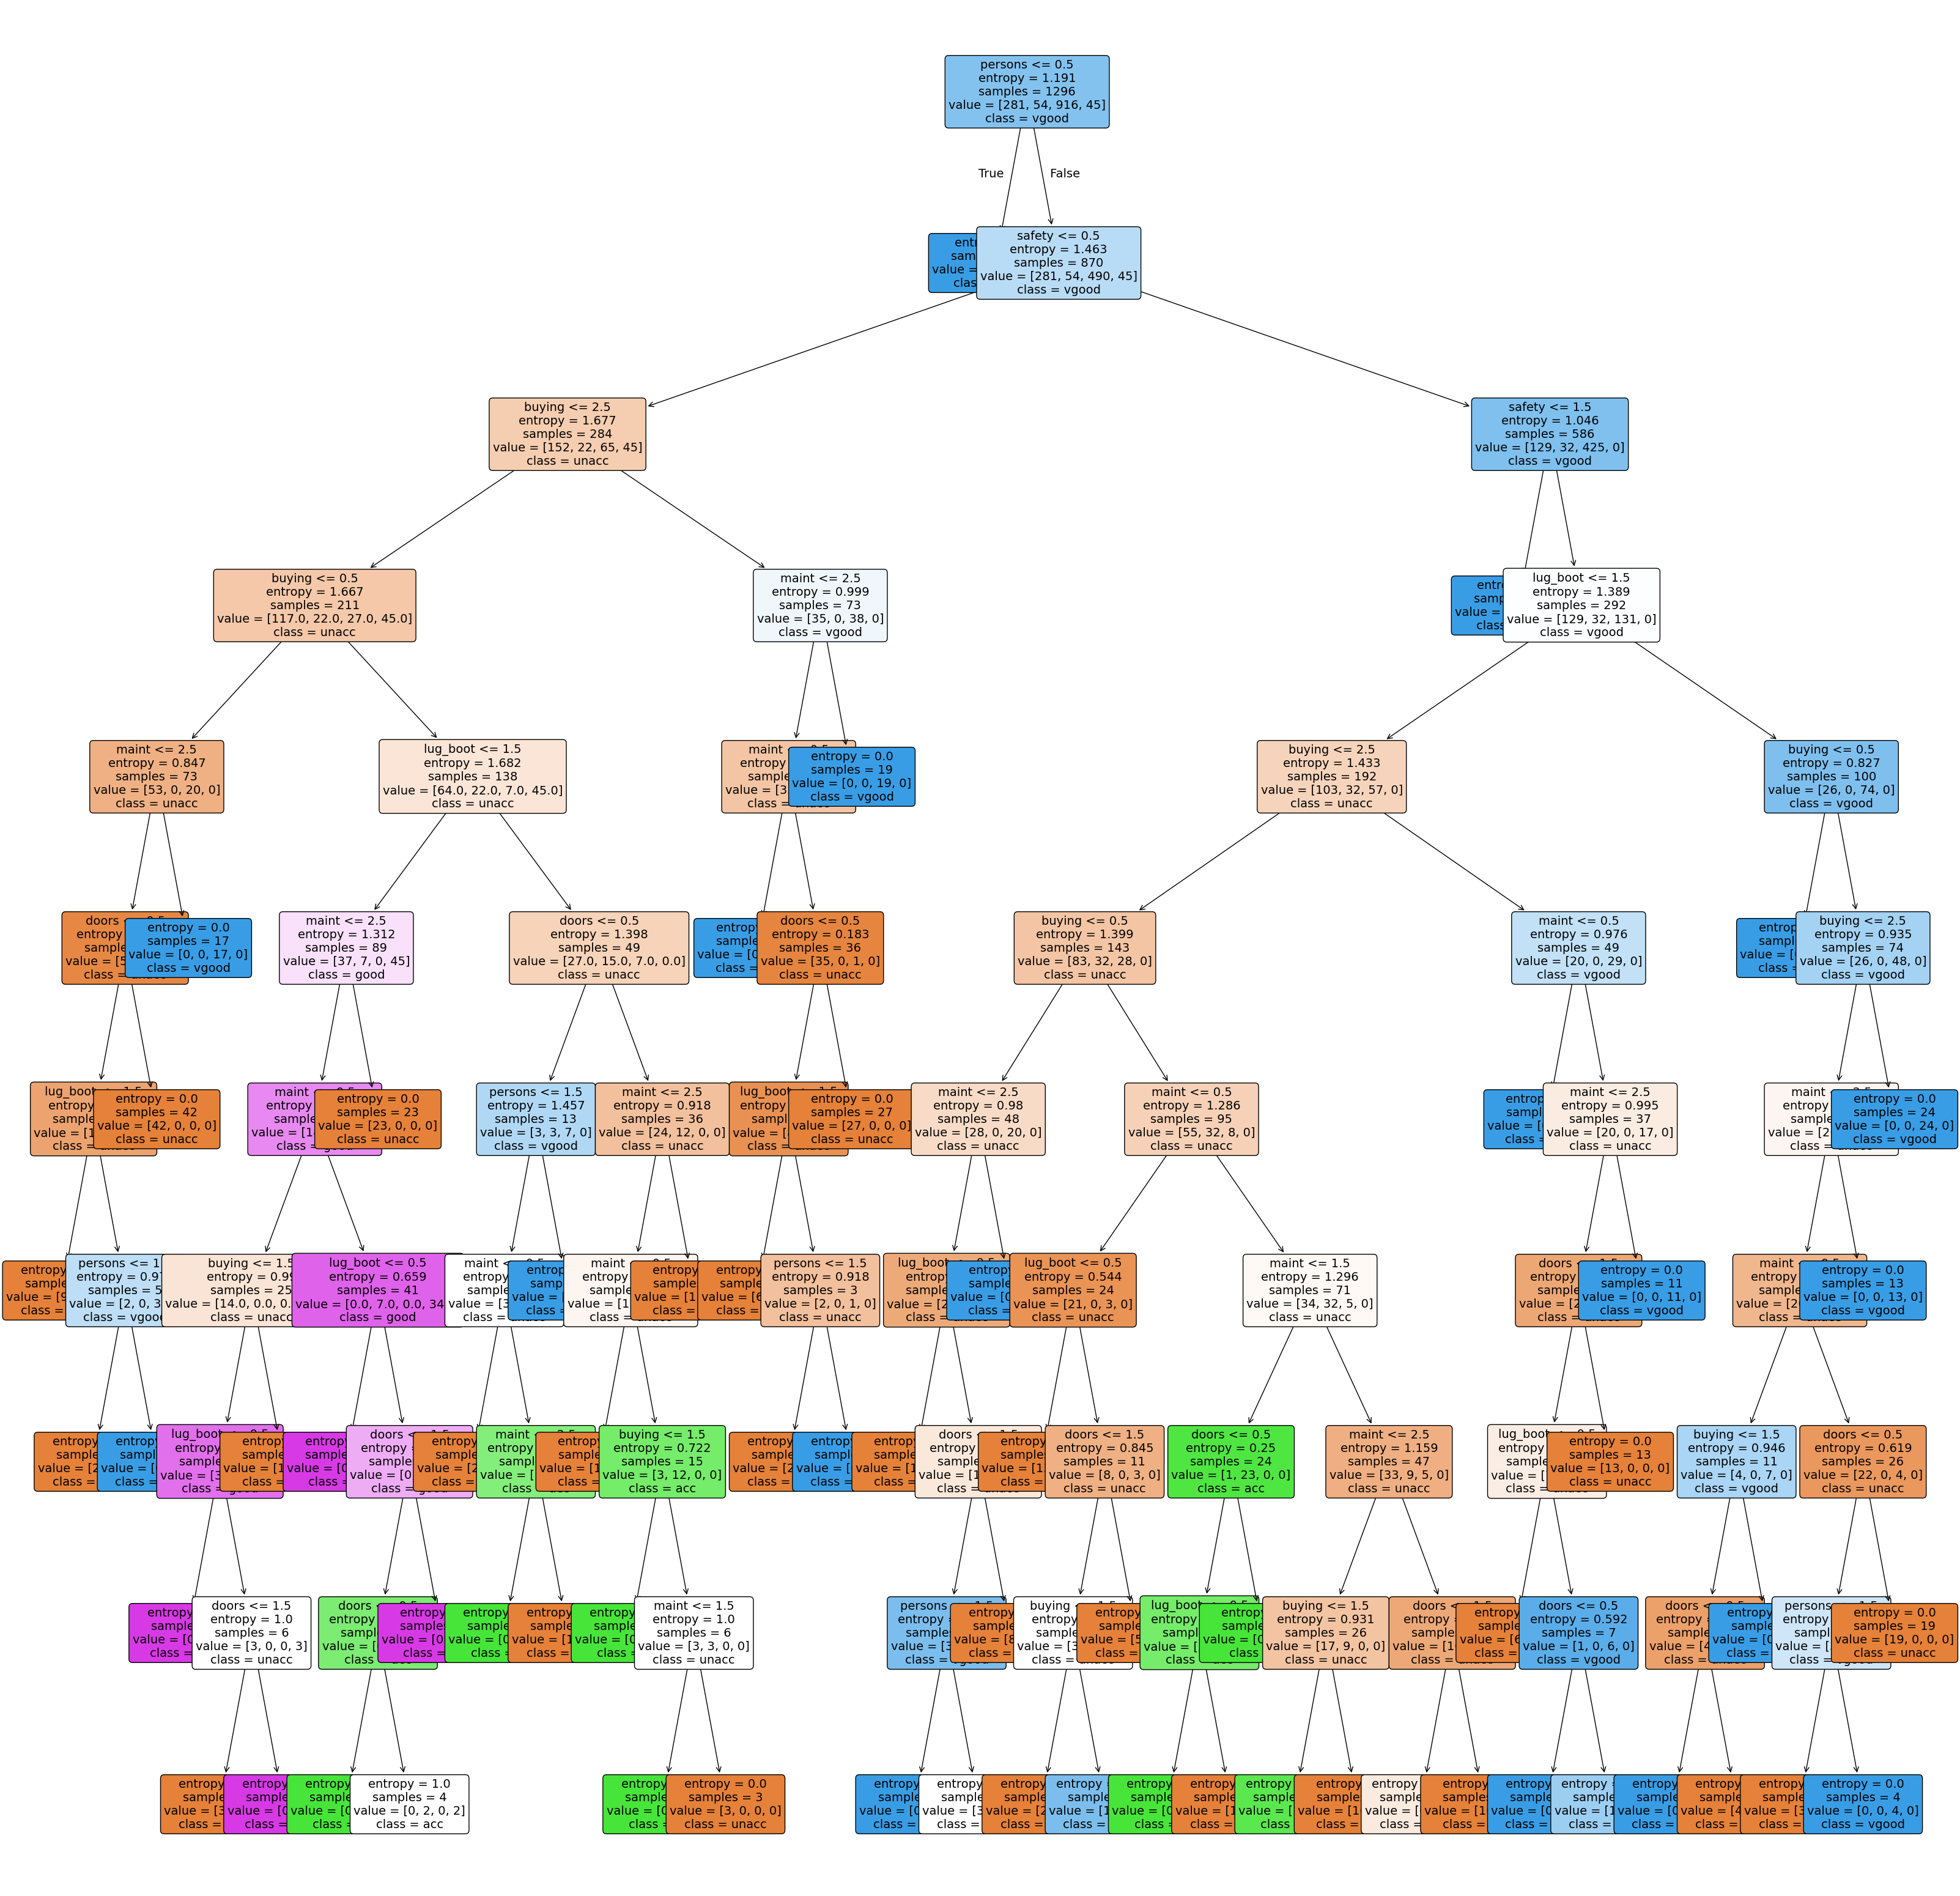

In [83]:
fig = plt.figure(figsize=(40,40))
a = tree.plot_tree(tree_clf,
                   feature_names = coulumn_names,
                   class_names = labels,
                   rounded = True, filled = True, fontsize=14)

In [84]:
y_pred_dt = tree_clf.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='macro')
precision_dt = precision_score(y_test, y_pred_dt, average='macro')
recall_dt = recall_score(y_test, y_pred_dt, average='macro')
accuracy_comaprison["Decision Tree"] = accuracy_dt
f1_comaprison["Decision Tree"] = f1_dt
precision_comaprison["Decision Tree"] = precision_dt
recall_comaprison["Decision Tree"] = recall_dt
print("Accuracy:",accuracy_dt, "F1 score:",f1_dt, "Precision:",precision_dt, "Recall:",recall_dt)

Accuracy: 0.9675925925925926 F1 score: 0.9008048699262621 Precision: 0.8930419268510259 Recall: 0.9373778152037514


# Random Forest Classifier

In [85]:
rf_classifier = RandomForestClassifier(max_depth=10, random_state=42, max_features=4, n_estimators=100, min_samples_split=2)
rf_classifier.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, max_features=4, random_state=42)

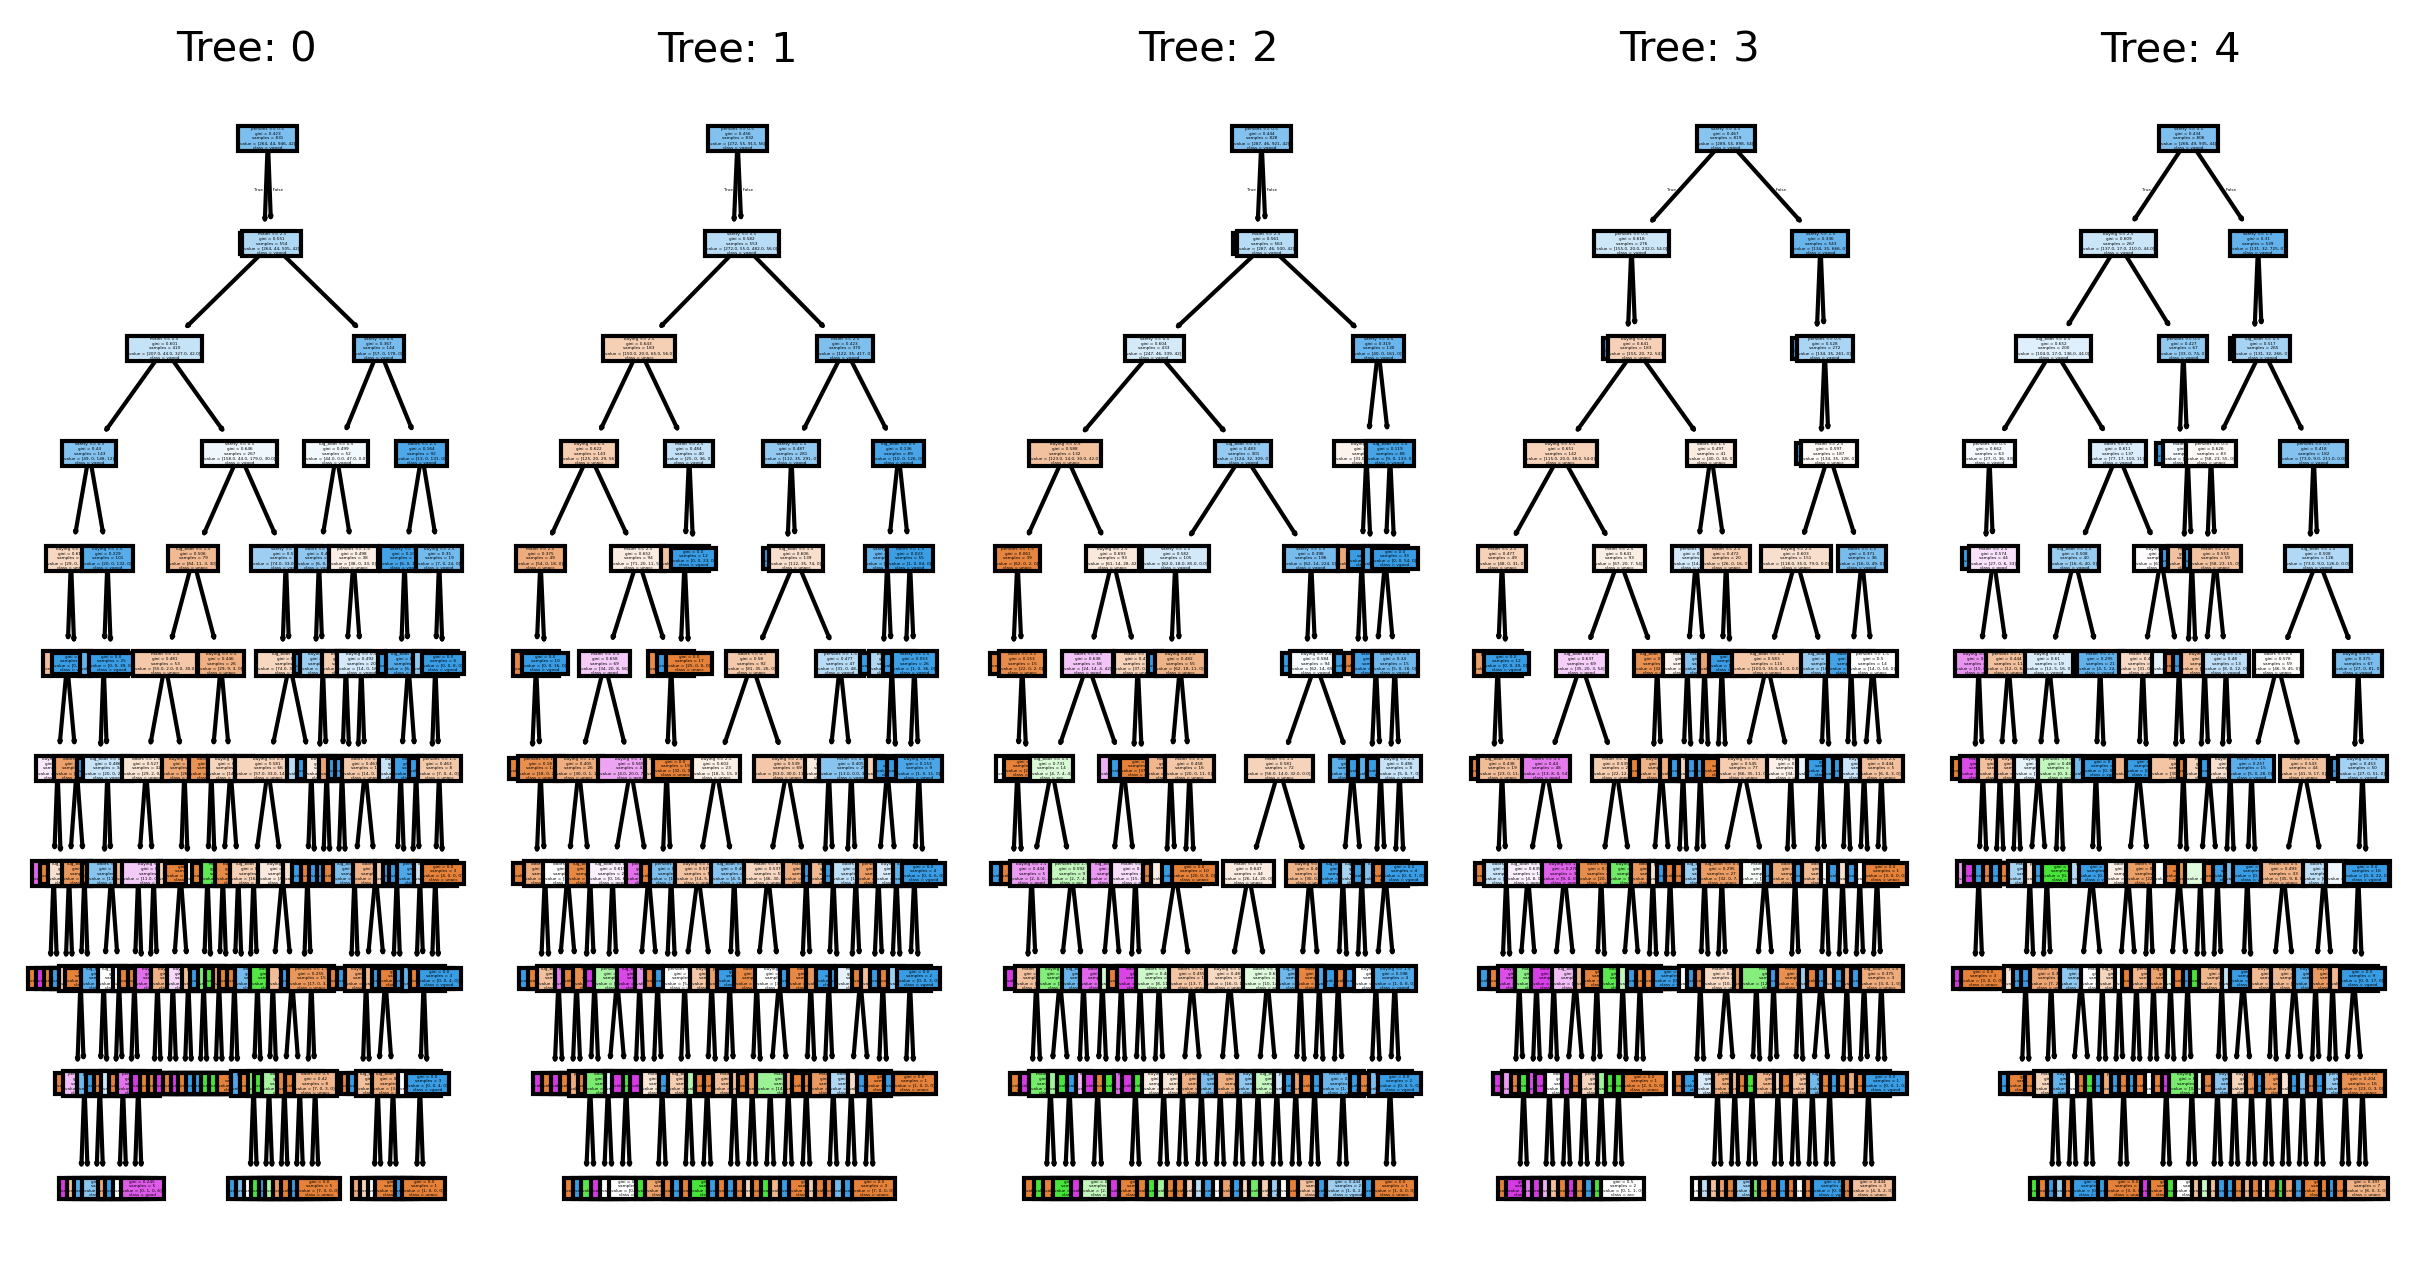

In [86]:
fig, axes = plt.subplots(nrows = 1,ncols = 5,figsize = (10,5), dpi=300)
for index in range(0, 5):
    tree.plot_tree(rf_classifier.estimators_[index], feature_names = coulumn_names, class_names=labels, filled = True, ax = axes[index])

    axes[index].set_title('Tree: ' + str(index), fontsize = 10)

In [87]:
y_pred_rf = rf_classifier.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
precision_rf = precision_score(y_test, y_pred_rf, average='macro')
recall_rf = recall_score(y_test, y_pred_rf, average='macro')
accuracy_comaprison["Random Forest"] = accuracy_rf
f1_comaprison["Random Forest"] = f1_rf
precision_comaprison["Random Forest"] = precision_rf
recall_comaprison["Random Forest"] = recall_rf
print("Accuracy:",accuracy_rf, "F1 score:",f1_rf, "Precision:",precision_rf, "Recall:",recall_rf)

Accuracy: 0.9629629629629629 F1 score: 0.8906903826776285 Precision: 0.8648941116608766 Recall: 0.9384295951390265


# Neural Network

In [101]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
le=LabelEncoder()
le.fit(np.concatenate((y_train, y_test)))
y_train_scaled = le.transform(y_train)
y_train_scaled = to_categorical(y_train_scaled)
y_test_scaled = le.transform(y_test)

In [107]:
def nn_model(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.2),

        Dense(64, activation='relu'),
        Dropout(0.2),

        Dense(32, activation='relu'),

        Dense(4, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [108]:
model = nn_model(X_train_scaled.shape[1])

In [109]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=30,
    batch_size=32,
    validation_split=0.3
)

Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6882 - loss: 1.0254 - val_accuracy: 0.6632 - val_loss: 0.7979
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7325 - loss: 0.6770 - val_accuracy: 0.6632 - val_loss: 0.7156
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7359 - loss: 0.6198 - val_accuracy: 0.6632 - val_loss: 0.6797
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7311 - loss: 0.6007 - val_accuracy: 0.6632 - val_loss: 0.6544
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7194 - loss: 0.5830 - val_accuracy: 0.6967 - val_loss: 0.6202
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7644 - loss: 0.5064 - val_accuracy: 0.7429 - val_loss: 0.5826
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7561 - loss: 0.5244 - val_accuracy: 0.7609 - val_loss: 0.5439
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8025 - loss: 0.4373 - val_accuracy: 0.7943 - val_loss

In [110]:
y_pred_nn_probs = model.predict(X_test_scaled)
y_pred_nn = np.argmax(y_pred_nn_probs, axis=1)
accuracy_nn = accuracy_score(y_test_scaled, y_pred_nn)
f1_nn = f1_score(y_test_scaled, y_pred_nn, average='macro')
precision_nn = precision_score(y_test_scaled, y_pred_nn, average='macro')
recall_nn = recall_score(y_test_scaled, y_pred_nn, average='macro')
accuracy_comaprison["Neural Network"] = accuracy_nn
f1_comaprison["Neural Network"] = f1_nn
precision_comaprison["Neural Network"] = precision_nn
recall_comaprison["Neural Network"] = recall_nn
print("Accuracy:",accuracy_nn, "F1 score:",f1_nn, "Precision:",precision_nn, "Recall:",recall_nn)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Accuracy: 0.9513888888888888 F1 score: 0.8884318178560126 Precision: 0.890808314702438 Recall: 0.8877418928736542


# Comparison

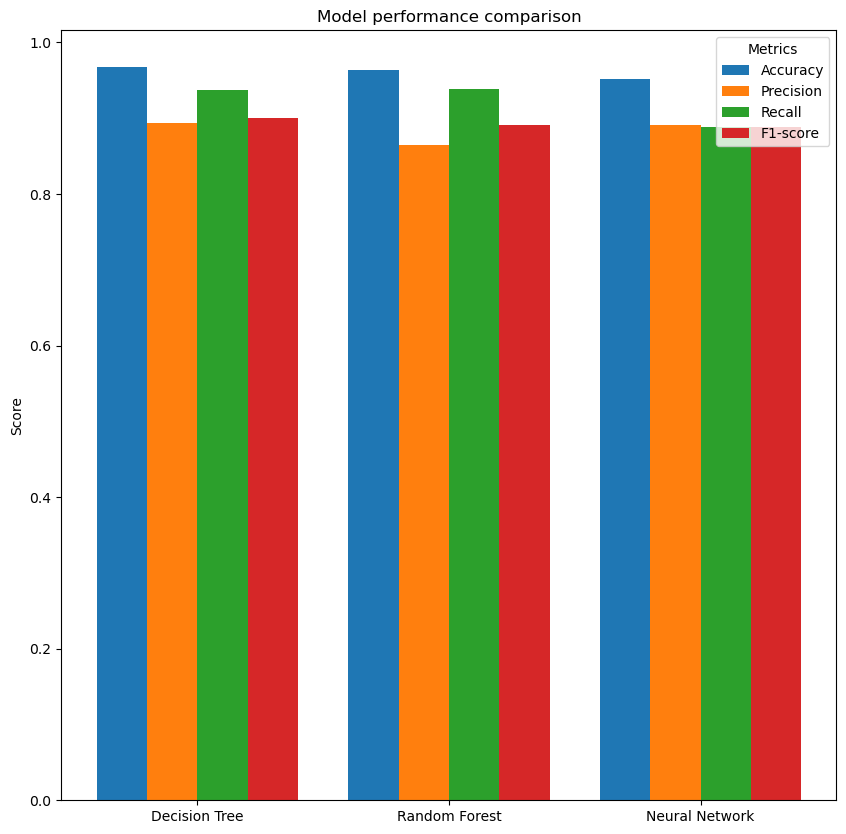

In [112]:
models = list(accuracy_comaprison.keys())

results = {}
for model in models:
    results[model] = {
        'Accuracy': accuracy_comaprison.get(model, 0),
        'Precision': precision_comaprison.get(model, 0),
        'Recall': recall_comaprison.get(model, 0),
        'F1-score': f1_comaprison.get(model, 0),
    }

df = pd.DataFrame(results).T

measures = df.columns.tolist()
models = df.index.tolist()

metrics = df.columns.tolist()
num_models = len(models)
num_metrics = len(metrics)

x = np.arange(num_models)
width = 0.2

fig, ax = plt.subplots(figsize=(10,10))

for i, metric in enumerate(metrics):
    ax.bar(x + i*width, df[metric], width, label=metric)

ax.set_xticks(x + width*(num_metrics-1)/2)
ax.set_xticklabels(models)

ax.set_ylabel('Score')
ax.set_title('Model performance comparison')
ax.legend(title='Metrics')

plt.show()

From the barchart we can see that the Decision Tree classifier has the best performance scores overall, with a negligible difference seen in Precision in the Neural Network model.